<a href="https://www.kaggle.com/code/himanshuraturi2302/notebook6ed0d0226c?scriptVersionId=311788972" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
import numpy as np


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [9]:
DATASET_PATH = "/kaggle/input/datasets/himanshuraturi2302/dataset/Comprehensive Disaster Dataset(CDD)/CDD_Augmented"  


In [10]:
dataset = datasets.ImageFolder(DATASET_PATH)

class_names = dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Total Images:", len(dataset))

Classes: ['Damaged_Infrastructure', 'Fire_Disaster', 'Human_Damage', 'Land_Disaster', 'Non_Damage', 'Water_Disaster']
Total Images: 18303


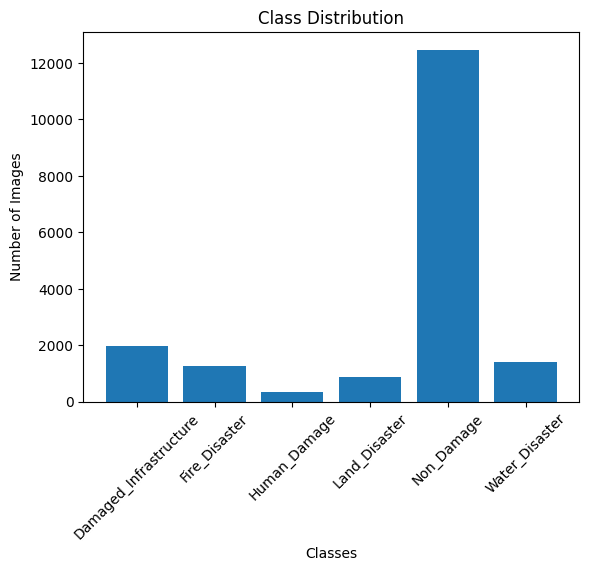

Class Count: {'Damaged_Infrastructure': np.int64(1963), 'Fire_Disaster': np.int64(1260), 'Human_Damage': np.int64(325), 'Land_Disaster': np.int64(887), 'Non_Damage': np.int64(12470), 'Water_Disaster': np.int64(1398)}


In [11]:
targets = dataset.targets
class_count = np.bincount(targets)

plt.figure()
plt.bar(class_names, class_count)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

print("Class Count:", dict(zip(class_names, class_count)))

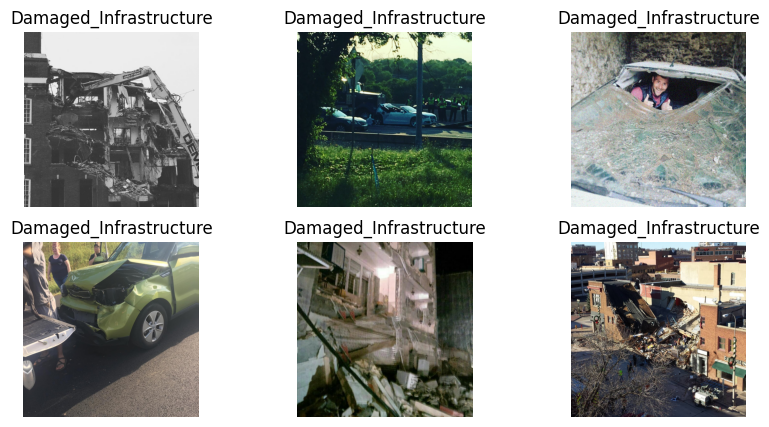

In [12]:
def show_samples(dataset, num_images=6):
    plt.figure(figsize=(10,5))
    for i in range(num_images):
        img, label = dataset[i]
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(class_names[label])
        plt.axis("off")
    plt.show()

show_samples(dataset)

Min Width: 150 Max Width: 4898
Min Height: 108 Max Height: 3123


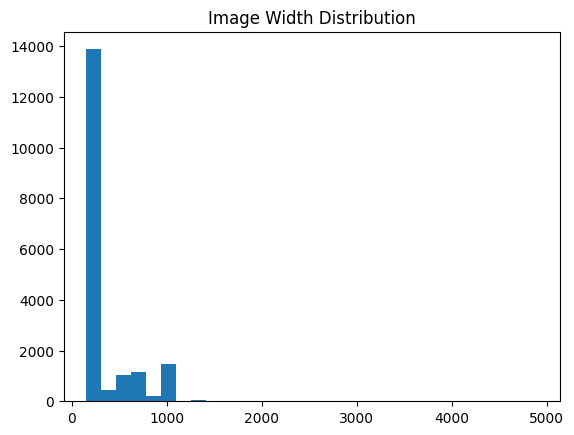

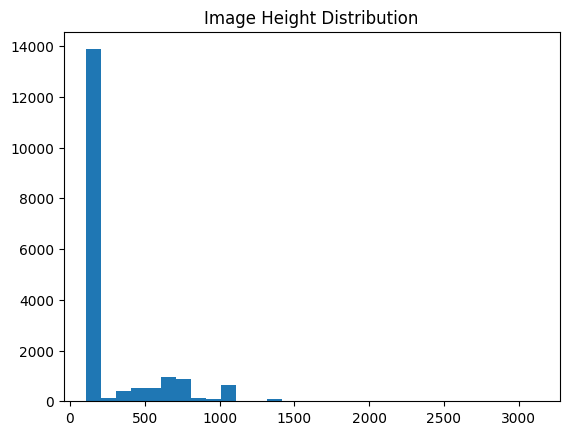

In [13]:
widths = []
heights = []

for i in range(len(dataset)):
    img, _ = dataset[i]
    w, h = img.size
    widths.append(w)
    heights.append(h)

print("Min Width:", min(widths), "Max Width:", max(widths))
print("Min Height:", min(heights), "Max Height:", max(heights))
plt.figure()
plt.hist(widths, bins=30)
plt.title("Image Width Distribution")
plt.show()

plt.figure()
plt.hist(heights, bins=30)
plt.title("Image Height Distribution")
plt.show()

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [15]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

# Apply transforms
train_data.dataset.transform = train_transform
val_data.dataset.transform = val_transform

print("Train size:", len(train_data))
print("Validation size:", len(val_data))

Train size: 14642
Validation size: 3661


In [16]:
BATCH_SIZE = 32

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 458
Validation batches: 115


In [17]:
# images, labels = next(iter(train_loader))

# print("Image batch shape:", images.shape)
# print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([4, 4, 4, 4, 4, 4, 3, 1, 4, 4])


In [18]:
mean = 0.
std = 0.
total_images = 0

for images, _ in train_loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images += batch_samples

mean /= total_images
std /= total_images

print("Mean:", mean)
print("Std:", std)

Mean: tensor([0.4348, 0.4333, 0.4054])
Std: tensor([0.2200, 0.2166, 0.2181])


In [19]:
class_weights = 1. / class_count
print("Class Weights:", class_weights)

Class Weights: [5.09424350e-04 7.93650794e-04 3.07692308e-03 1.12739572e-03
 8.01924619e-05 7.15307582e-04]


In [ ]:
full_dataset = ImageFolder(DATASET_PATH, transform=transform)

# Class names
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

In [ ]:
BATCH_SIZE = 32
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),

    transforms.RandomGrayscale(p=0.1),

    transforms.GaussianBlur(kernel_size=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
full_dataset = ImageFolder(DATASET_PATH)

class_names = full_dataset.classes
print("Classes:", class_names)


In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_data, val_data = random_split(full_dataset, [train_size, val_size])

In [ ]:
train_data.dataset.transform = train_transform
val_data.dataset.transform = val_transform

In [ ]:
targets = full_dataset.targets
class_count = np.bincount(targets)

print("Class distribution:", class_count)

# Compute weights (inverse frequency)
class_weights = 1. / class_count
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


In [ ]:
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

In [ ]:
val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_data, val_data = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)

In [ ]:
'''for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Fake severity labels (demo purpose)
        severity_labels = labels % 3

        out1, out2 = model(images)

        loss1 = criterion1(out1, labels)
        loss2 = criterion2(out2, severity_labels)

        loss = loss1 + loss2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {total_loss:.4f}")

print("\n Training Complete!")'''